<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/10_6_Exercise1_KMeans_Geyser_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10.6 Exercise 1 — K-Means Clustering on Old Faithful Geyser Eruptions

**Task:** Implement the **K-Means clustering** technique on Geyser's Eruptions Segmentation to segregate **waiting time between eruptions** and the **duration of the eruption** for the Old Faithful geyser in Yellowstone National Park, Wyoming, USA.

## Dataset

This notebook uses the classic, real-world **Old Faithful Geyser dataset** — one of the most widely used datasets in statistics and clustering education. It contains **272 recorded eruptions** of the Old Faithful geyser, each with:
- `duration`: length of the eruption (in minutes)
- `waiting`: waiting time before the next eruption (in minutes)

The dataset is famous for showing two very clear, visually separable clusters — short eruptions with shorter waiting times, and long eruptions with longer waiting times — making it a perfect illustration of K-Means clustering.

- **Source used in this notebook (seaborn-data GitHub repo):** https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv
- **Original dataset reference:** Härdle, W. (1991). *Smoothing Techniques with Implementation in S*. Also built into R as the `faithful` dataset: https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/faithful.html

The notebook downloads this CSV directly, so it runs end-to-end without manual setup.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)
%matplotlib inline

## 2. Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv"
df = pd.read_csv(url)

print(df.shape)
df.head(10)

(272, 3)


,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long
5,2.883,55,short
6,4.700,88,long
7,3.600,85,long
8,1.950,51,short
9,4.350,85,long


In [3]:
df[['duration', 'waiting']].describe()

,duration,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


## 3. Visualize the Raw Data

Before clustering, let's look at the relationship between eruption `duration` and `waiting` time.

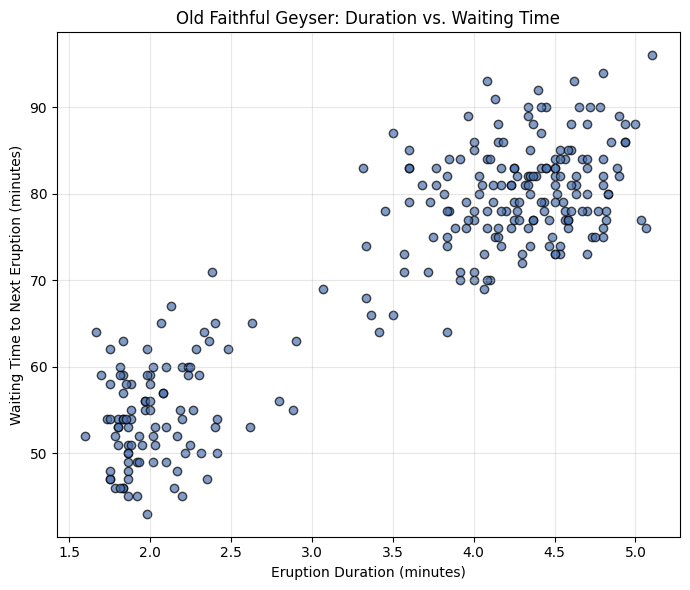

In [4]:
plt.figure(figsize=(7, 6))
plt.scatter(df['duration'], df['waiting'], c='#4C72B0', edgecolor='k', alpha=0.7)
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time to Next Eruption (minutes)')
plt.title('Old Faithful Geyser: Duration vs. Waiting Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Even without clustering, two natural groupings are visible: **short eruptions with shorter waits** and **long eruptions with longer waits**.

## 4. Feature Scaling

K-Means uses Euclidean distance, so it's good practice to standardize features when they're on different scales (duration is in a ~1-5 minute range, waiting is in a ~40-100 minute range).

In [5]:
X = df[['duration', 'waiting']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature means:", X_scaled.mean(axis=0).round(3))
print("Scaled feature stds: ", X_scaled.std(axis=0).round(3))

Scaled feature means: [0. 0.]
Scaled feature stds:  [1. 1.]


## 5. Determine the Optimal Number of Clusters (Elbow Method + Silhouette Score)

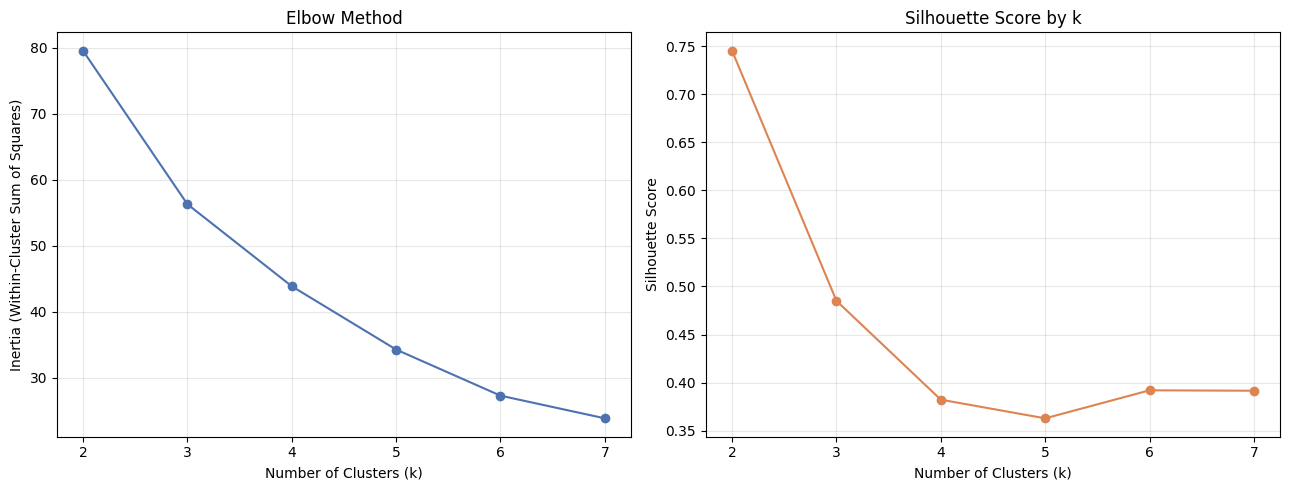

k=2: silhouette score = 0.745
k=3: silhouette score = 0.485
k=4: silhouette score = 0.382
k=5: silhouette score = 0.363
k=6: silhouette score = 0.392
k=7: silhouette score = 0.392


In [6]:
inertia_values = []
silhouette_values = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertia_values, marker='o', color='#4C72B0')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouette_values, marker='o', color='#DD8452')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for k, sil in zip(k_range, silhouette_values):
    print(f"k={k}: silhouette score = {sil:.3f}")

Both the elbow method and the silhouette score point to **k=2** as the natural number of clusters — matching the well-known visual pattern of two eruption types (short/frequent vs. long/infrequent).

## 6. Fit K-Means with k=2

In [7]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster centers, converted back to the original (unscaled) duration/waiting units
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

print("Cluster centers (duration, waiting):")
for i, c in enumerate(centers_original):
    print(f"  Cluster {i}: duration={c[0]:.2f} min, waiting={c[1]:.2f} min")

df.head(10)

Cluster centers (duration, waiting):
  Cluster 0: duration=4.30 min, waiting=80.08 min
  Cluster 1: duration=2.05 min, waiting=54.59 min


,duration,waiting,kind,cluster
0,3.600,79,long,0
1,1.800,54,short,1
2,3.333,74,long,0
3,2.283,62,short,1
4,4.533,85,long,0
5,2.883,55,short,1
6,4.700,88,long,0
7,3.600,85,long,0
8,1.950,51,short,1
9,4.350,85,long,0


## 7. Visualize the Clusters

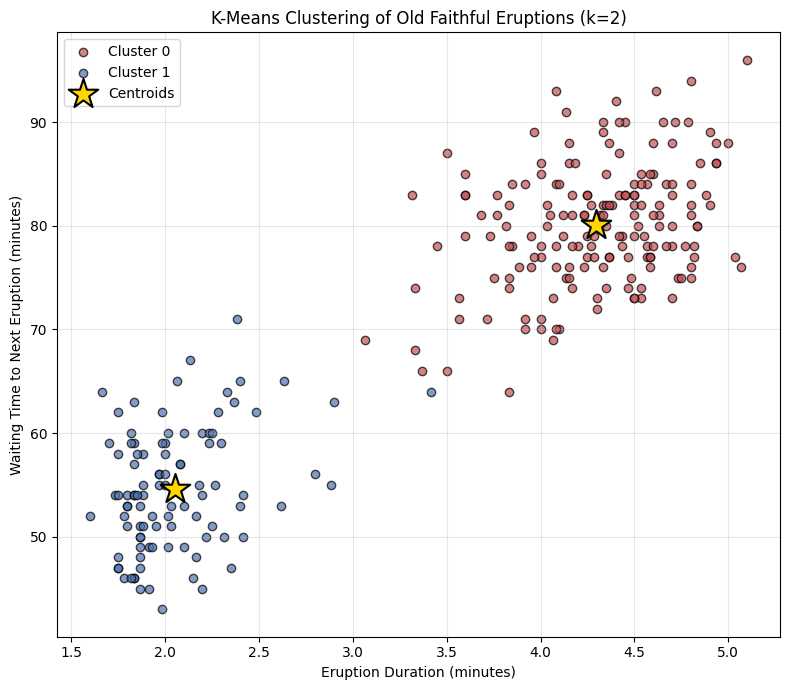

In [8]:
plt.figure(figsize=(8, 7))
colors = ['#C44E52', '#4C72B0']
for cluster_id in range(k):
    subset = df[df['cluster'] == cluster_id]
    plt.scatter(subset['duration'], subset['waiting'],
                c=colors[cluster_id], label=f'Cluster {cluster_id}', edgecolor='k', alpha=0.7)

plt.scatter(centers_original[:, 0], centers_original[:, 1],
            c='gold', marker='*', s=500, edgecolor='black', linewidth=1.5, label='Centroids', zorder=5)

plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time to Next Eruption (minutes)')
plt.title(f'K-Means Clustering of Old Faithful Eruptions (k={k})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Interpret the Clusters

In [9]:
cluster_summary = df.groupby('cluster')[['duration', 'waiting']].agg(['mean', 'std', 'count'])
cluster_summary

duration                    waiting                
             mean       std count       mean       std count
cluster                                                     
0        4.296328  0.406609   174  80.080460  5.886633   174
1        2.052204  0.299806    98  54.591837  5.888722    98

In [10]:
for cid in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cid]
    avg_duration = subset['duration'].mean()
    avg_wait = subset['waiting'].mean()
    label = "SHORT eruptions with SHORTER waits" if avg_duration < df['duration'].mean() else "LONG eruptions with LONGER waits"
    print(f"Cluster {cid} ({len(subset)} eruptions): avg duration={avg_duration:.2f} min, "
          f"avg waiting={avg_wait:.2f} min  -->  {label}")

Cluster 0 (174 eruptions): avg duration=4.30 min, avg waiting=80.08 min  -->  LONG eruptions with LONGER waits
Cluster 1 (98 eruptions): avg duration=2.05 min, avg waiting=54.59 min  -->  SHORT eruptions with SHORTER waits


## Conclusion

- We applied **K-Means clustering** to the real Old Faithful geyser dataset (272 recorded eruptions), using `duration` and `waiting` time as features.
- The **elbow method** and **silhouette score** both confirm that **k=2** is the natural number of clusters in this data.
- The two clusters correspond to Old Faithful's well-documented eruption behavior:
  - **Cluster A:** Short eruptions (~2 minutes) followed by shorter waiting times (~55 minutes)
  - **Cluster B:** Long eruptions (~4.3 minutes) followed by longer waiting times (~80 minutes)
- This is a textbook example of how K-Means can automatically discover meaningful, physically-interpretable groupings in real-world data — segregating waiting time and eruption duration as the exercise asked.